In [ ]:
import os
import zipfile
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
from google.colab import drive

# Path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/Hand Gesture Dataset.zip'

# Extract path (where you want to extract the contents)
extract_path = '/content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the extracted files
extracted_files = os.listdir(extract_path)
print("Extracted Files:")
for file in extracted_files:
    print(file)


Extracted Files:
.config
leapgestrecog
drive
leapGestRecog
sample_data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import random
import seaborn as sns


# **Data Exploration & Visualization**

In [ ]:
# Path to the extracted dataset folder
dataset= '/content/leapGestRecog'

# List only folders within the dataset
dataset_folders = [f for f in os.listdir(dataset) if os.path.isdir(os.path.join(dataset, f))]
print("Folders within the Dataset:")
for folder in dataset_folders:
    print(folder)


Folders within the Dataset:
09
06
05
03
08
04
00
02
07
01


In [ ]:
hand_gestures = ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down' ]


In [ ]:
def count_images_per_class(dataset_folders):
    image_counts = {}
    total_images = 0
    for folder in dataset_folders:
        folder_num = folder.split('_')[0]
        for gesture in hand_gestures:  # Assuming hand_gestures_classes is defined elsewhere
            path = os.path.join(dataset, folder, gesture)
            images = os.listdir(path)
            key = f" {folder_num}: {gesture}"  # Create a key with both Class_num and gesture_class
            image_counts[key] = len(images)
            total_images += len(images)  # Update total image count
    return image_counts, total_images

# Count images in each hand gesture class before splitting
image_counts_before, total_images = count_images_per_class(dataset_folders)
print("Number of images in each hand gesture class before splitting:")
for key, value in image_counts_before.items():
    print(f"{key}: {value}")
print("\nTotal number of images before splitting:", total_images)


Number of images in each hand gesture class before splitting:
 09: 01_palm: 200
 09: 02_l: 200
 09: 03_fist: 200
 09: 04_fist_moved: 200
 09: 05_thumb: 200
 09: 06_index: 200
 09: 07_ok: 200
 09: 08_palm_moved: 200
 09: 09_c: 200
 09: 10_down: 200
 06: 01_palm: 200
 06: 02_l: 200
 06: 03_fist: 200
 06: 04_fist_moved: 200
 06: 05_thumb: 200
 06: 06_index: 200
 06: 07_ok: 200
 06: 08_palm_moved: 200
 06: 09_c: 200
 06: 10_down: 200
 05: 01_palm: 200
 05: 02_l: 200
 05: 03_fist: 200
 05: 04_fist_moved: 200
 05: 05_thumb: 200
 05: 06_index: 200
 05: 07_ok: 200
 05: 08_palm_moved: 200
 05: 09_c: 200
 05: 10_down: 200
 03: 01_palm: 200
 03: 02_l: 200
 03: 03_fist: 200
 03: 04_fist_moved: 200
 03: 05_thumb: 200
 03: 06_index: 200
 03: 07_ok: 200
 03: 08_palm_moved: 200
 03: 09_c: 200
 03: 10_down: 200
 08: 01_palm: 200
 08: 02_l: 200
 08: 03_fist: 200
 08: 04_fist_moved: 200
 08: 05_thumb: 200
 08: 06_index: 200
 08: 07_ok: 200
 08: 08_palm_moved: 200
 08: 09_c: 200
 08: 10_down: 200
 04: 01_

In [ ]:
def count_images_per_gesture(dataset_folders):
    gesture_counts = {gesture: 0 for gesture in hand_gestures}
    for folder in dataset_folders:
        path = os.path.join(dataset, folder)
        for gesture in hand_gestures:
            gesture_path = os.path.join(path, gesture)
            images = os.listdir(gesture_path)
            gesture_counts[gesture] += len(images)

    print("Total number of images in each hand gesture:")
    for gesture, count in gesture_counts.items():
        print(f" {gesture}: {count}")

# Count images in each hand gesture
count_images_per_gesture(dataset_folders)

Total number of images in each hand gesture:
 01_palm: 2000
 02_l: 2000
 03_fist: 2000
 04_fist_moved: 2000
 05_thumb: 2000
 06_index: 2000
 07_ok: 2000
 08_palm_moved: 2000
 09_c: 2000
 10_down: 2000


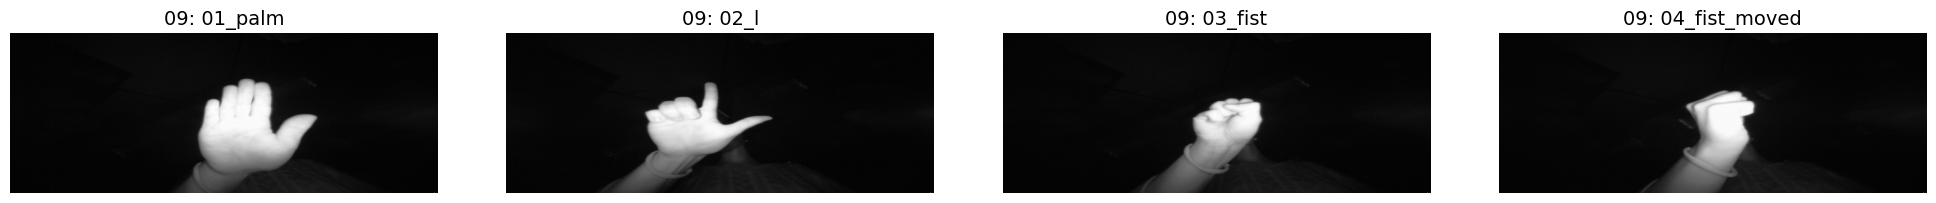

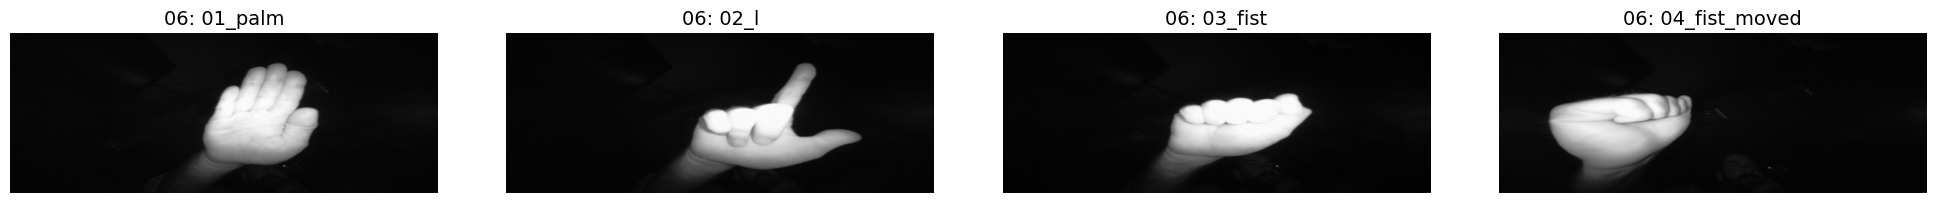

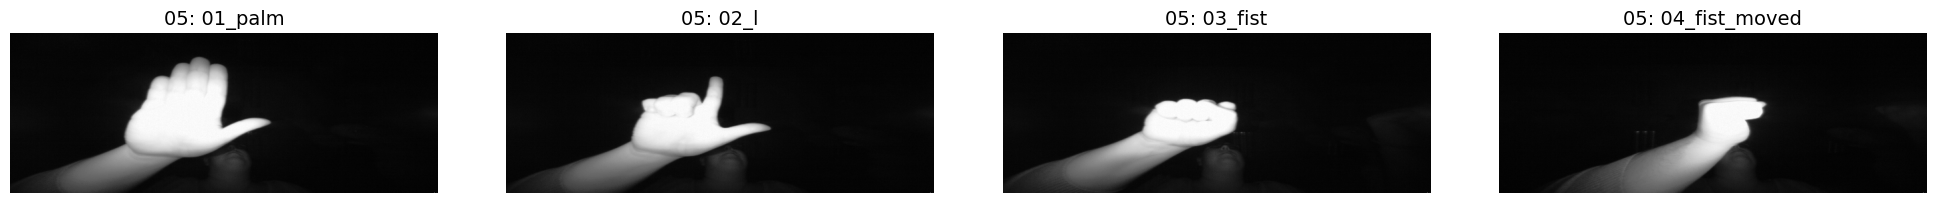

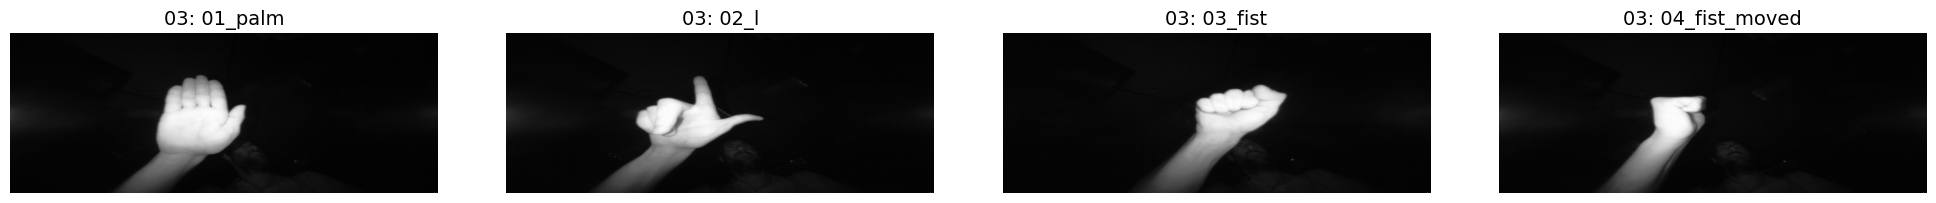

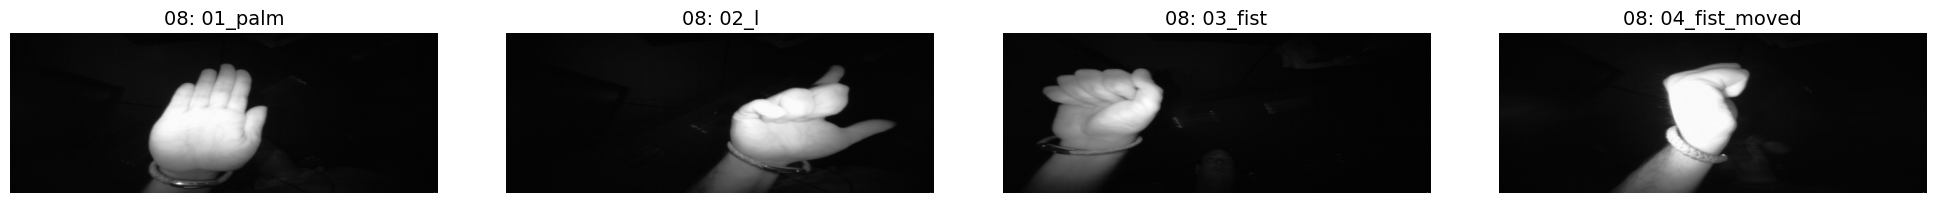

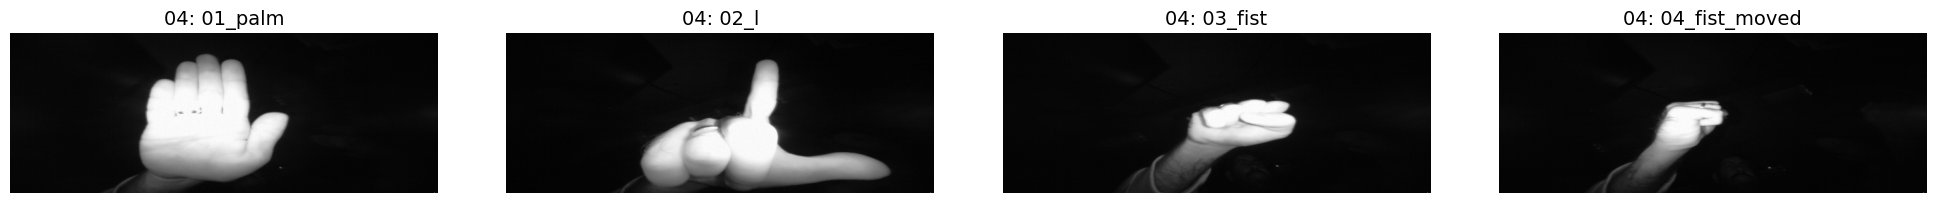

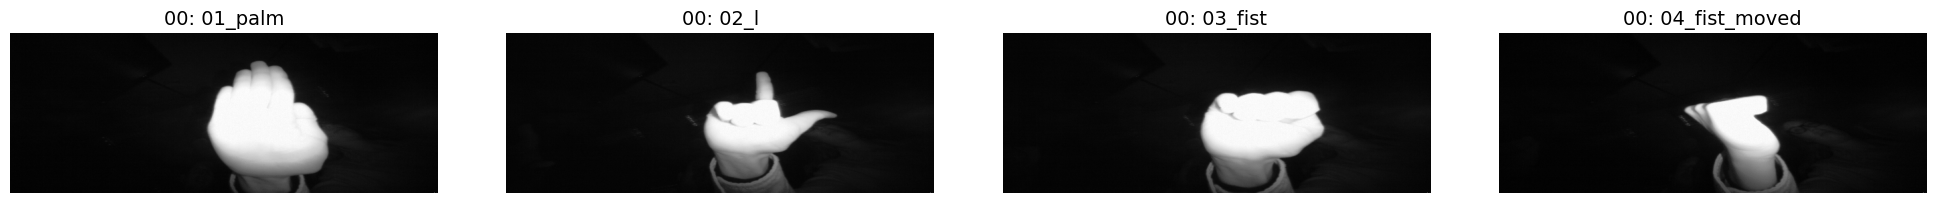

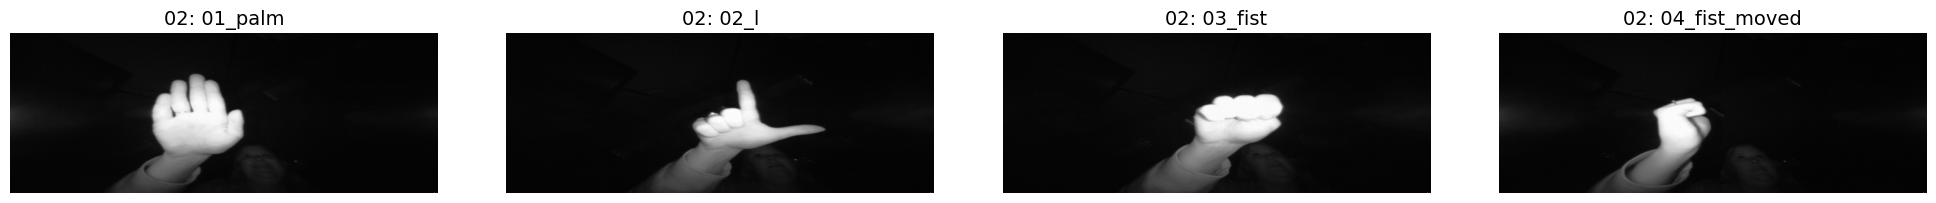

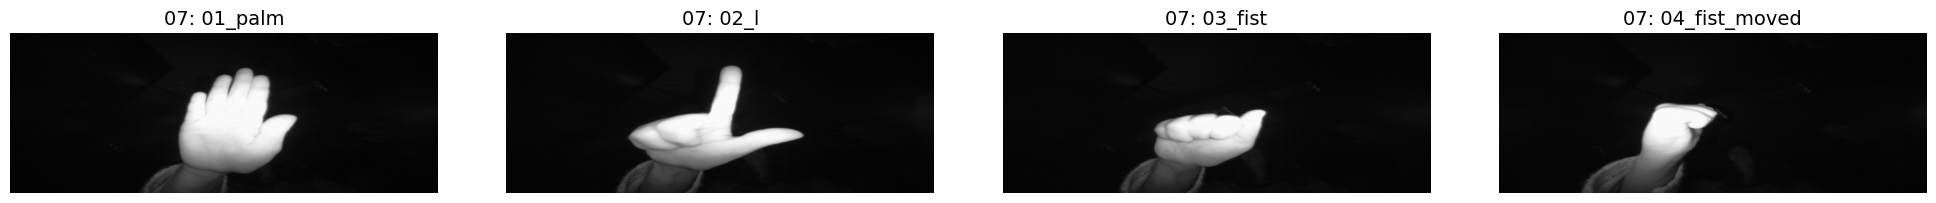

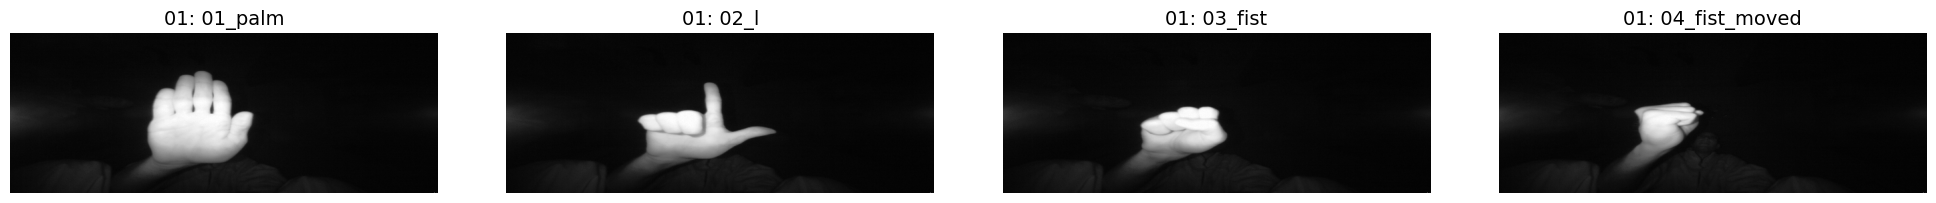

In [ ]:
#DATA DSPLAY

# Loop through folders and classes to display images
for folder in dataset_folders:
    folder_num = folder.split('_')[0]
    fig, axes = plt.subplots(1, 4, figsize=(20, 2))  # Create a row for each folder containing 4 images
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    img_count = 0  # Count the number of images displayed in this row
    for gesture in hand_gestures:
        path = os.path.join(dataset, folder, gesture)
        images = os.listdir(path)
        if images and img_count < 4:  # Display only the first 10 images
            img_array = cv2.imread(os.path.join(path, images[0]), cv2.IMREAD_GRAYSCALE)  # Read only the first image
            axes[img_count].imshow(img_array, cmap='gray')
            axes[img_count].set_title(f"{folder_num}: {gesture}", fontsize=14)
            axes[img_count].axis('off')  # Turn off axis labels
            img_count += 1
    plt.tight_layout()  # Adjust spacing between images
    plt.show()  # Show each row of images

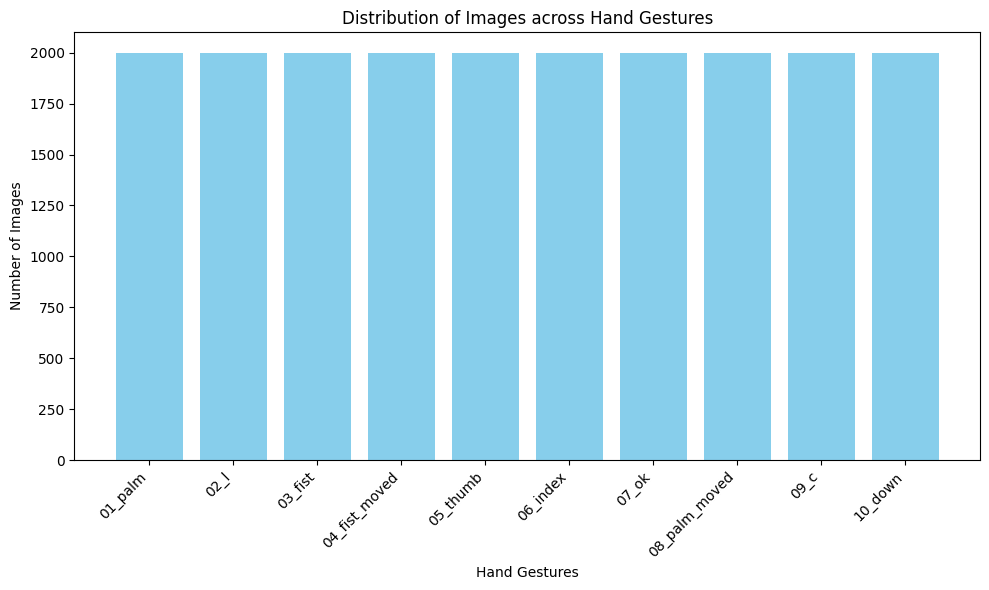

In [ ]:
import matplotlib.pyplot as plt

# Dictionary containing the counts of images per hand gesture
gesture_counts = {
    '01_palm': 2000,
    '02_l': 2000,
    '03_fist': 2000,
    '04_fist_moved': 2000,
    '05_thumb': 2000,
    '06_index': 2000,
    '07_ok': 2000,
    '08_palm_moved': 2000,
    '09_c': 2000,
    '10_down': 2000
}

# Extracting gesture labels and corresponding counts
labels = list(gesture_counts.keys())
counts = list(gesture_counts.values())

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Hand Gestures')
plt.ylabel('Number of Images')
plt.title('Distribution of Images across Hand Gestures')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# CHECK IMAGE SIZES

def check_image_sizes(dataset_folders, hand_gestures):
    first_img_shape = None
    for folder in dataset_folders:
        for gesture in hand_gestures:
            path = os.path.join(dataset, folder, gesture)

            for img in os.listdir(path):
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                if first_img_shape is None:
                    first_img_shape = img_array.shape
                elif img_array.shape != first_img_shape:
                    print(f"Image '{img}' in '{gesture}' does not have the expected size.")
                    return False
    print("All images have the same size:", first_img_shape)


  # Check image sizes within the dataset folders
check_image_sizes(dataset_folders, hand_gestures)

All images have the same size: (240, 640)


In [ ]:
# CHECK IMAGES EXTENTIONS

def check_image_extensions(dataset_folders, hand_gestures):
    first_img_extension = None
    for folder in dataset_folders:
        for gesture in hand_gestures:
            path = os.path.join(dataset, folder, gesture)

            for img in os.listdir(path):
                _, img_extension = os.path.splitext(img)

                if first_img_extension is None:
                    first_img_extension = img_extension
                elif img_extension != first_img_extension:
                    print(f"Image '{img}' in '{gesture}' does not have the expected extension.")
                    return False

    print("All images have the same extension:", first_img_extension)


# Check image extensions within the dataset folders
result = check_image_extensions(dataset_folders, hand_gestures)


All images have the same extension: .png


**PRE-PROCESSING**

In [ ]:
import os
from PIL import Image, ImageEnhance

# Function to apply sharpness enhancement
def apply_sharpness_enhancement(image):
    enhancer = ImageEnhance.Sharpness(image)
    sharpened_img = enhancer.enhance(6.0)  # Adjust the enhancement factor as needed
    return sharpened_img

# Define paths
dataset = '/content/leapGestRecog'
sharpened_folder= '/content/sharpened_gestures'

os.makedirs(sharpened_folder, exist_ok=True)  # Create the sharpened images folder if it doesn't exist

# Processed gestures dictionary to keep track of processed gestures
sharpened_images = []

for folder in os.listdir(dataset):
    folder_path = os.path.join(dataset, folder)
    if os.path.isdir(folder_path):
        for gesture in os.listdir(folder_path):
            gesture_path = os.path.join(folder_path, gesture)
            if os.path.isdir(gesture_path):
                # Create a folder in sharpened images directory for each gesture
                gesture_save_path = os.path.join(sharpened_folder, gesture)
                os.makedirs(gesture_save_path, exist_ok=True)

                for img_name in os.listdir(gesture_path):
                    if img_name.endswith('.png') or img_name.endswith('.jpg') or img_name.endswith('.jpeg'):
                        img_path = os.path.join(gesture_path, img_name)
                        img = Image.open(img_path)
                        sharpened_img = apply_sharpness_enhancement(img)

                        # Save the sharpened image to the appropriate gesture folder
                        save_name = os.path.join(gesture_save_path, img_name)
                        sharpened_img.save(save_name)

                        sharpened_images.append((img_path, save_name))

print("Number of processed images:", len(sharpened_images))

Number of processed images: 20000


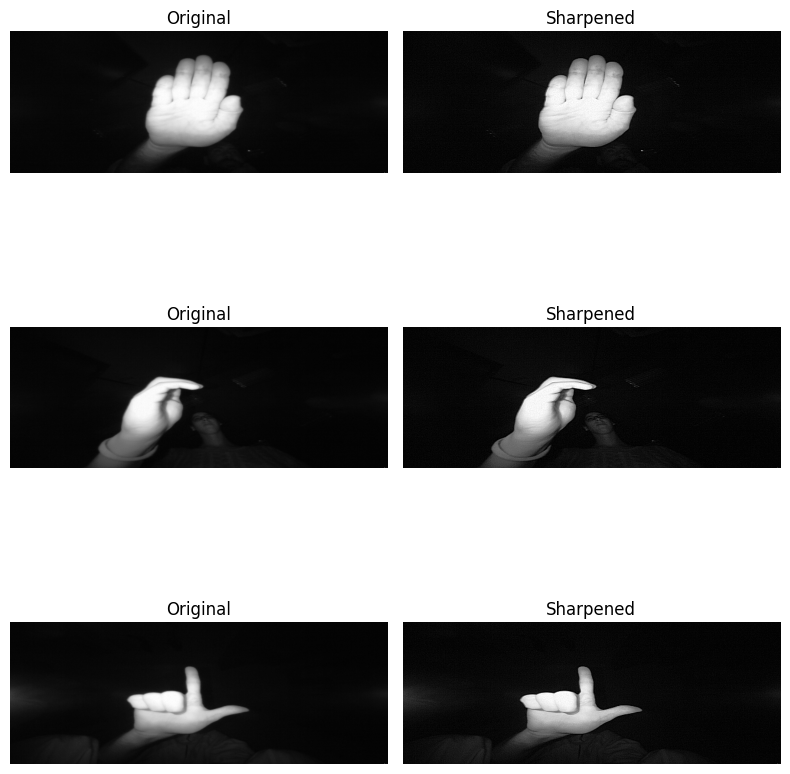

In [ ]:
# Select 3 random samples
random_samples = random.sample(sharpened_images, 3)

# Plot the images
fig, axs = plt.subplots(3, 2, figsize=(8, 10))

for i, (original_img_path, sharpened_img_path) in enumerate(random_samples):
    # Display original image
    original_img = Image.open(original_img_path).convert('L')  # Convert to grayscale
    axs[i, 0].imshow(original_img, cmap='gray')
    axs[i, 0].axis('off')
    axs[i, 0].set_title('Original')

    # Display sharpened image
    sharpened_img = Image.open(sharpened_img_path)
    axs[i, 1].imshow(sharpened_img, cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title('Sharpened')

plt.tight_layout()
plt.show()


**FEATURES EXTRACTION**

**SIFT**

In [ ]:
import cv2
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Function to extract SIFT features from an image
def extract_sift_features(image_path):
    # Load the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Initialize SIFT detector
    sift = cv2.SIFT_create()

    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(img, None)

    return keypoints, descriptors

# List to store SIFT keypoints and descriptors for all sharpened images
sift_features = []

# Total number of descriptors
total_descriptors = 0

# Iterate through all sharpened images
for original_img_path, sharpened_img_path in sharpened_images:
    # Extract SIFT features from the sharpened image
    keypoints, descriptors = extract_sift_features(sharpened_img_path)

    # Increment the total number of descriptors
    total_descriptors += descriptors.shape[0]

    # Store the SIFT features along with the image paths
    sift_features.append((original_img_path, sharpened_img_path, keypoints, descriptors))



In [ ]:
print(f"Total number of images processed: {len(sift_features)}")
print(f"Total number of Descriptors: {total_descriptors}")
print(f"Number of SIFT features extracted: {sum(len(desc[1]) for desc in sift_features)}")


Total number of images processed: 20000
Total number of Descriptors: 1222820
Number of SIFT features extracted: 1132000


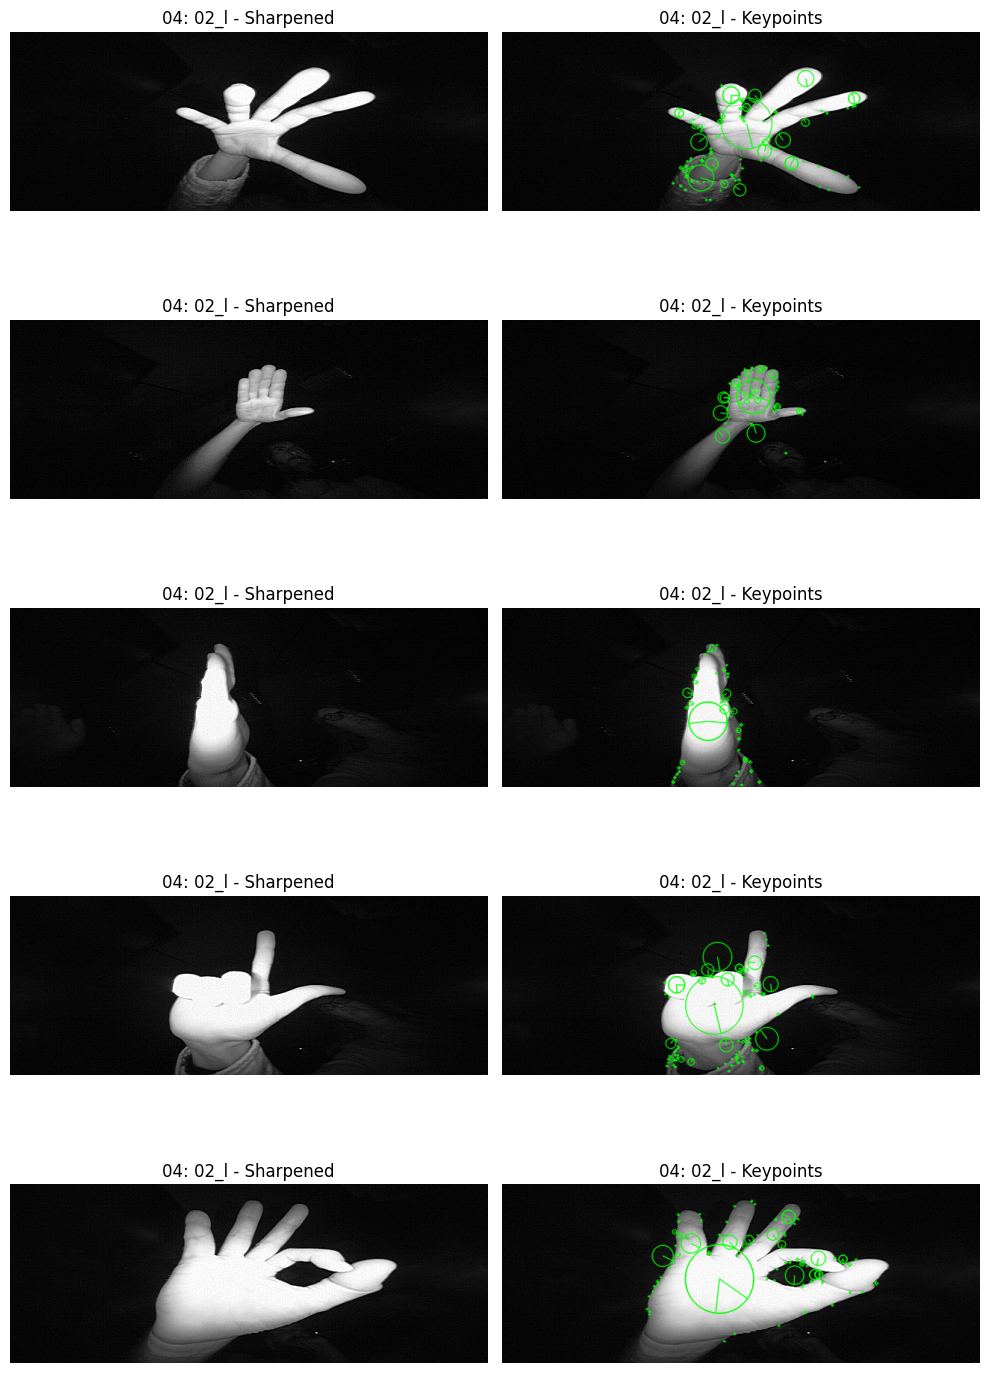

In [ ]:
# Select 5 random samples from sift_features
random_samples = random.sample(sift_features, 5)

# Plot the images with keypoints
fig, axs = plt.subplots(5, 2, figsize=(10, 15))

for i, (original_img_path, sharpened_img_path, keypoints, descriptors) in enumerate(random_samples):
    # Load the sharpened image
    sharpened_img = cv2.imread(sharpened_img_path, cv2.IMREAD_GRAYSCALE)

    # Draw keypoints on the image
    img_with_keypoints = cv2.drawKeypoints(sharpened_img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Display the image with keypoints
    axs[i, 0].imshow(Image.open(sharpened_img_path), cmap='gray')  # Sharpened image
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f"{folder_num}: {gesture} - Sharpened")

    axs[i, 1].imshow(img_with_keypoints, cmap='gray')  # Image with keypoints
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f"{folder_num}: {gesture} - Keypoints")

plt.tight_layout()
plt.show()


**Pre-Split Preparation**

In [ ]:
import numpy as np

# Initialize lists to store features and labels
features = []
labels = []

# Define the desired length for descriptors
desired_length = 128

for original_img_path, sharpened_img_path, _, descriptors in sift_features:
    # Check if descriptors are valid
    if descriptors is not None and descriptors.shape[0] > 0:
        # Pad or truncate descriptors to the desired length
        if descriptors.shape[0] < desired_length:
            descriptors = np.pad(descriptors, ((0, desired_length - descriptors.shape[0]), (0, 0)), mode='constant')
        elif descriptors.shape[0] > desired_length:
            descriptors = descriptors[:desired_length, :]

        # Flatten descriptors and append to features list
        features.append(descriptors.flatten())

        # Extract label information based on folder structure
        label = os.path.basename(os.path.dirname(sharpened_img_path))  # Use a single variable for the label

        # Append label information to labels list
        labels.append((label))
    else:
        print(f"No valid descriptors found for image: {sharpened_img_path}")

# Convert lists to numpy arrays
X = np.array(features)
y = np.array(labels)

# Display the shape of features and labels arrays
print("Shape of features array:", X.shape)
print("Shape of labels array:", y.shape)


Shape of features array: (20000, 16384)
Shape of labels array: (20000,)


In [ ]:
# Split the dataset into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the shapes of eatures and labels to check the dimensions
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)

(16000, 16384)
(16000,)
(2000, 16384)
(2000,)
(2000, 16384)
(2000,)


In [ ]:
#Get classes names after splitting
print(np.unique(y_train))

print(np.unique(y_test))

['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']
['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


In [ ]:
# Get unique class names from y_test
unique_classes = np.unique(hand_gestures)

# Create a dictionary to map numerical labels to class names
labels_dict = {label: class_name for label, class_name in enumerate(unique_classes)}

# Print the dictionary to check the mapping
print(labels_dict)


{0: '01_palm', 1: '02_l', 2: '03_fist', 3: '04_fist_moved', 4: '05_thumb', 5: '06_index', 6: '07_ok', 7: '08_palm_moved', 8: '09_c', 9: '10_down'}


In [ ]:
import numpy as np

# If the unique values are not integers representing classes, you may need to adjust the label encoding
# For example, if they are one-hot encoded, you can convert them back to integer labels using np.argmax
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
y_train_labels = np.argmax(y_train, axis=1)


In [ ]:
# Check unique values in y_val_labels and y_test_labels after conversion
print("Unique values in y_val_labels:", np.unique(y_val_labels))
print("Unique values in y_test_labels:", np.unique(y_test_labels))


Unique values in y_val_labels: [0]
Unique values in y_test_labels: [0]


**MACHINE LEARNING**

# **KNN**

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Assuming you have already prepared your features (X) and labels (y) arrays

# Initialize the KNN classifier
knn_clf = KNeighborsClassifier(n_neighbors=3)  # You can adjust the number of neighbors (k) as needed

# Train the classifier on the training data
knn_clf.fit(X_train, y_train)

# Make predictions on the validation data
y_val_pred = knn_clf.predict(X_val)

# Evaluate the model's accuracy on validation data
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy on Validation Set: {val_accuracy:.2f}")

# Make predictions on the test data
y_test_pred_knn = knn_clf.predict(X_test)

# Evaluate the model's accuracy on test data
test_accuracy = accuracy_score(y_test, y_test_pred_knn)
print(f"Accuracy on Test Set: {test_accuracy:.2f}")



Accuracy on Validation Set: 0.86
Accuracy on Test Set: 0.86


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix for KNN classifier
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

# Print confusion matrix
print("Confusion Matrix (KNN):")
print(cm_knn)

# Generate classification report
report_knn = classification_report(y_test, y_test_pred_knn)
print("\nClassification Report (KNN):")
print(report_knn)


Confusion Matrix (KNN):
[[189   2   2   0   3   1   0  12   0   0]
 [  4 159   8   0   4   4   0   5   0   0]
 [  3   3 173   2  10   5   0   5   0   0]
 [  4   2   6 168   1   0   0  13   0   0]
 [  5   4  14   1 189   4   1   2   0   0]
 [  5   5  15   0   6 160   0   1   0   0]
 [  8   2   4   1   6   4 173   4   0   0]
 [  1   0   0   0   2   1   0 186   0   0]
 [  2   1   3   6   0   0   1  25 184   0]
 [ 10   9   7   1   8   5   0  12   1 133]]

Classification Report (KNN):
               precision    recall  f1-score   support

      01_palm       0.82      0.90      0.86       209
         02_l       0.85      0.86      0.86       184
      03_fist       0.75      0.86      0.80       201
04_fist_moved       0.94      0.87      0.90       194
     05_thumb       0.83      0.86      0.84       220
     06_index       0.87      0.83      0.85       192
        07_ok       0.99      0.86      0.92       202
08_palm_moved       0.70      0.98      0.82       190
         09_c      

# **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Assuming you have already prepared your features (X) and labels (y) arrays

# Initialize the SVM classifier
svm_clf = SVC(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', etc.

# Train the classifier on the training data
svm_clf.fit(X_train, y_train)

# Make predictions on the validation data
y_val_pred = svm_clf.predict(X_val)

# Evaluate the model's accuracy on validation data
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy on Validation Set (SVM): {val_accuracy:.2f}")

# Make predictions on the test data
y_test_pred = svm_clf.predict(X_test)

# Evaluate the model's accuracy on test data
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy on Test Set (SVM): {test_accuracy:.2f}")


Accuracy on Validation Set (SVM): 0.94
Accuracy on Test Set (SVM): 0.94


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix for SVM classifier
cm_svm = confusion_matrix(y_test, y_test_pred)

# Print confusion matrix
print("Confusion Matrix (SVM):")
print(cm_svm)

# Generate classification report
report_svm = classification_report(y_test, y_test_pred)
print("\nClassification Report (SVM):")
print(report_svm)


Confusion Matrix (SVM):
[[199   3   3   2   0   2   0   0   0   0]
 [  0 178   1   0   3   2   0   0   0   0]
 [  2   5 177   2   4   8   0   1   2   0]
 [  1   0   1 185   1   0   0   2   3   1]
 [  0   7  13   3 192   1   0   0   2   2]
 [  0   4  10   0   6 168   2   0   0   2]
 [  0   0   0   0   0   1 200   0   0   1]
 [  0   0   1   0   0   0   1 187   1   0]
 [  1   0   1   7   0   0   2   2 207   2]
 [  0   3   0   0   1   0   4   0   0 178]]

Classification Report (SVM):
               precision    recall  f1-score   support

      01_palm       0.98      0.95      0.97       209
         02_l       0.89      0.97      0.93       184
      03_fist       0.86      0.88      0.87       201
04_fist_moved       0.93      0.95      0.94       194
     05_thumb       0.93      0.87      0.90       220
     06_index       0.92      0.88      0.90       192
        07_ok       0.96      0.99      0.97       202
08_palm_moved       0.97      0.98      0.98       190
         09_c      

# **RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Assuming you have already prepared your features (X) and labels (y) arrays

# Initialize the Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust the number of trees (n_estimators) as needed

# Train the classifier on the training data
rf_clf.fit(X_train, y_train)

# Make predictions on the validation data
y_val_pred = rf_clf.predict(X_val)

# Evaluate the model's accuracy on validation data
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy on Validation Set (Random Forest): {val_accuracy:.2f}")

# Make predictions on the test data
y_test_pred= rf_clf.predict(X_test)

# Evaluate the model's accuracy on test data
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy on Test Set (Random Forest): {test_accuracy:.2f}")


Accuracy on Validation Set (Random Forest): 0.77
Accuracy on Test Set (Random Forest): 0.75


# **CONFUSION MATRIX**

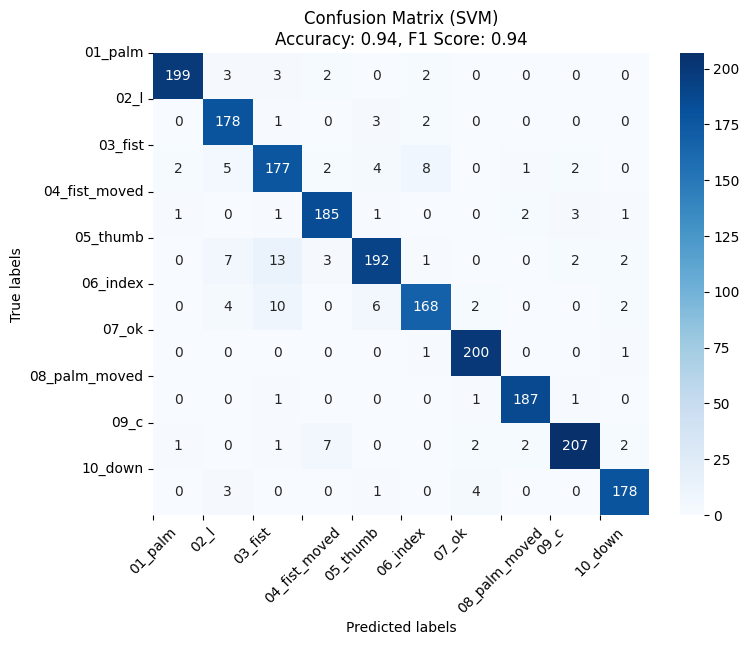

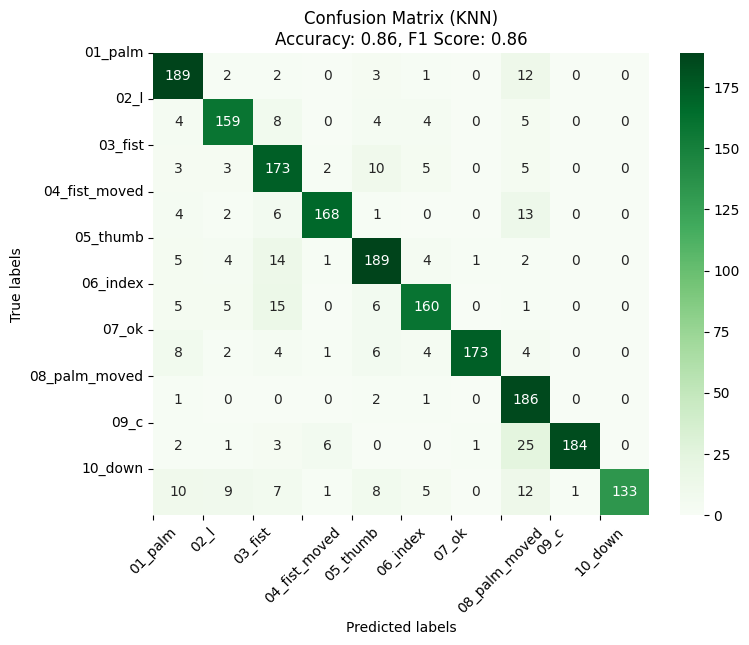

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import numpy as np

# Compute confusion matrix for SVM classifier
cm_svm = confusion_matrix(y_test, y_test_pred)

# Compute accuracy and F1 score for SVM classifier
accuracy_svm = accuracy_score(y_test, y_test_pred)
f1_svm = f1_score(y_test, y_test_pred, average='micro')

# Display colorful confusion matrix for SVM classifier with class labels
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title(f'Confusion Matrix (SVM)\nAccuracy: {accuracy_svm:.2f}, F1 Score: {f1_svm:.2f}')
plt.xticks(ticks=np.arange(len(unique_classes)), labels=[labels_dict[label] for label in np.arange(len(unique_classes))], rotation=45)
plt.yticks(ticks=np.arange(len(unique_classes)), labels=[labels_dict[label] for label in np.arange(len(unique_classes))], rotation=0)
plt.show()

# Compute confusion matrix for KNN classifier
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

# Compute accuracy and F1 score for KNN classifier
accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
f1_knn = f1_score(y_test, y_test_pred_knn, average='micro')

# Display colorful confusion matrix for KNN classifier with class labels
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, cmap='Greens', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title(f'Confusion Matrix (KNN)\nAccuracy: {accuracy_knn:.2f}, F1 Score: {f1_knn:.2f}')
plt.xticks(ticks=np.arange(len(unique_classes)), labels=[labels_dict[label] for label in np.arange(len(unique_classes))], rotation=45)
plt.yticks(ticks=np.arange(len(unique_classes)), labels=[labels_dict[label] for label in np.arange(len(unique_classes))], rotation=0)
plt.show()



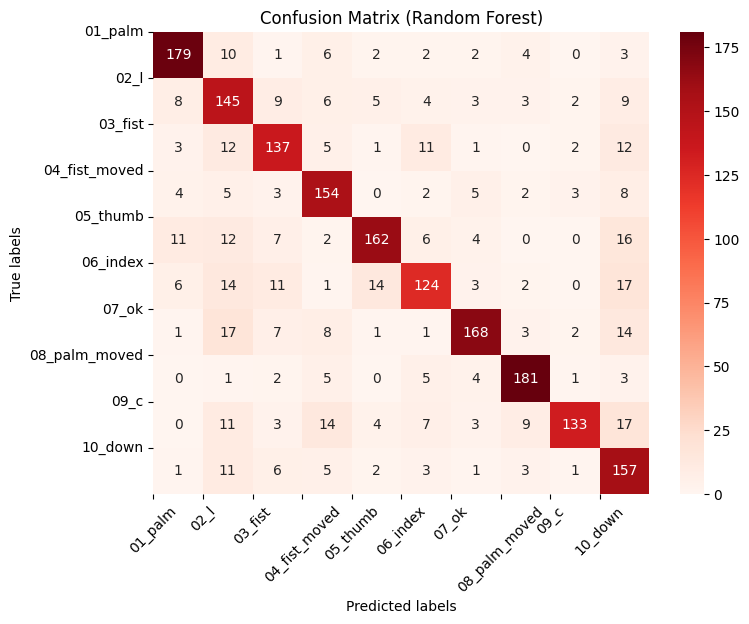

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained your Random Forest classifier and made predictions on the test data

# Compute confusion matrix for Random Forest classifier
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

# Display colorful confusion matrix for Random Forest classifier with class labels
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, cmap='Reds', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Random Forest)')
plt.xticks(ticks=np.arange(len(unique_classes)), labels=[labels_dict[label] for label in np.arange(len(unique_classes))], rotation=45)
plt.yticks(ticks=np.arange(len(unique_classes)), labels=[labels_dict[label] for label in np.arange(len(unique_classes))], rotation=0)
plt.show()


# **REPORT**

In [ ]:
from tabulate import tabulate

# Calculate metrics for SVM
class_metrics_svm = {}
for i, class_name in enumerate(unique_classes):
    tn_svm = np.sum(np.delete(np.delete(cm_svm, i, axis=0), i, axis=1))  # True negatives
    tp_svm = cm_svm[i, i]  # True positives
    fp_svm = np.sum(cm_svm[:, i]) - tp_svm  # False positives
    fn_svm = np.sum(cm_svm[i, :]) - tp_svm  # False negatives

    accuracy_svm = (tp_svm + tn_svm) / (tp_svm + tn_svm + fp_svm + fn_svm)
    sensitivity_svm = tp_svm / (tp_svm + fn_svm)
    specificity_svm = tn_svm / (tn_svm + fp_svm)
    precision_svm = tp_svm / (tp_svm + fp_svm)
    f1_svm = 2 * (precision_svm * sensitivity_svm) / (precision_svm + sensitivity_svm)

    class_metrics_svm[class_name] = {
        'Accuracy': accuracy_svm,
        'Sensitivity': sensitivity_svm,
        'Specificity': specificity_svm,
        'Precision': precision_svm,
        'F1 Score': f1_svm
    }

# Convert metrics to a table format
table_headers = ['Class Name', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score']
table_data = []
for class_name, metrics in class_metrics_svm.items():
    table_data.append([class_name, metrics['Accuracy'], metrics['Sensitivity'], metrics['Specificity'],
                       metrics['Precision'], metrics['F1 Score']])

# Print the table
print(tabulate(table_data, headers=table_headers, tablefmt='grid'))


+---------------+------------+---------------+---------------+-------------+------------+
| Class Name    |   Accuracy |   Sensitivity |   Specificity |   Precision |   F1 Score |
+===============+============+===============+===============+=============+============+
| 01_palm       |     0.993  |      0.952153 |      0.997767 |    0.980296 |   0.966019 |
+---------------+------------+---------------+---------------+-------------+------------+
| 02_l          |     0.986  |      0.967391 |      0.987885 |    0.89     |   0.927083 |
+---------------+------------+---------------+---------------+-------------+------------+
| 03_fist       |     0.973  |      0.880597 |      0.983324 |    0.855072 |   0.867647 |
+---------------+------------+---------------+---------------+-------------+------------+
| 04_fist_moved |     0.9885 |      0.953608 |      0.992248 |    0.929648 |   0.941476 |
+---------------+------------+---------------+---------------+-------------+------------+
| 05_thumb

In [ ]:
from tabulate import tabulate


# Calculate metrics for KNN
class_metrics_knn = {}
for i, class_name in enumerate(unique_classes):
    tn_knn = np.sum(np.delete(np.delete(cm_knn, i, axis=0), i, axis=1))  # True negatives
    tp_knn = cm_knn[i, i]  # True positives
    fp_knn = np.sum(cm_knn[:, i]) - tp_knn  # False positives
    fn_knn = np.sum(cm_knn[i, :]) - tp_knn  # False negatives

    accuracy_knn = (tp_knn + tn_knn) / (tp_knn + tn_knn + fp_knn + fn_knn)
    sensitivity_knn = tp_knn / (tp_knn + fn_knn)
    specificity_knn = tn_knn / (tn_knn + fp_knn)
    precision_knn = tp_knn / (tp_knn + fp_knn)
    f1_knn = 2 * (precision_knn * sensitivity_knn) / (precision_knn + sensitivity_knn)

    class_metrics_knn[class_name] = {
        'Accuracy': accuracy_knn,
        'Sensitivity': sensitivity_knn,
        'Specificity': specificity_knn,
        'Precision': precision_knn,
        'F1 Score': f1_knn
    }

# Convert metrics to a table format for KNN
table_headers_knn = ['Class Name', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score']
table_data_knn = []
for class_name, metrics in class_metrics_knn.items():
    table_data_knn.append([class_name, metrics['Accuracy'], metrics['Sensitivity'], metrics['Specificity'],
                           metrics['Precision'], metrics['F1 Score']])

# Print the table for KNN
print(tabulate(table_data_knn, headers=table_headers_knn, tablefmt='grid'))


+---------------+------------+---------------+---------------+-------------+------------+
| Class Name    |   Accuracy |   Sensitivity |   Specificity |   Precision |   F1 Score |
+===============+============+===============+===============+=============+============+
| 01_palm       |     0.969  |      0.904306 |      0.976549 |    0.818182 |   0.859091 |
+---------------+------------+---------------+---------------+-------------+------------+
| 02_l          |     0.9735 |      0.86413  |      0.984581 |    0.850267 |   0.857143 |
+---------------+------------+---------------+---------------+-------------+------------+
| 03_fist       |     0.9565 |      0.860697 |      0.967204 |    0.74569  |   0.799076 |
+---------------+------------+---------------+---------------+-------------+------------+
| 04_fist_moved |     0.9815 |      0.865979 |      0.993909 |    0.938547 |   0.900804 |
+---------------+------------+---------------+---------------+-------------+------------+
| 05_thumb

**ROC CURVE**

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize


# Binarize the labels for multi-class ROC curve
y_val_bin = label_binarize(y_val, classes=np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.unique(y))

# Predict probabilities for each class
y_val_score_knn = knn_clf.predict_proba(X_val)
y_test_score_knn = knn_clf.predict_proba(X_test)
y_val_score_svm = svm_clf.decision_function(X_val)
y_test_score_svm = svm_clf.decision_function(X_test)


In [ ]:
# Assuming y_test contains the true labels for your test set

# Get unique class names from y_test
unique_classes = np.unique(y_test)

# Create a dictionary to map numerical labels to class names
labels_dict = {label: class_name for label, class_name in enumerate(unique_classes)}


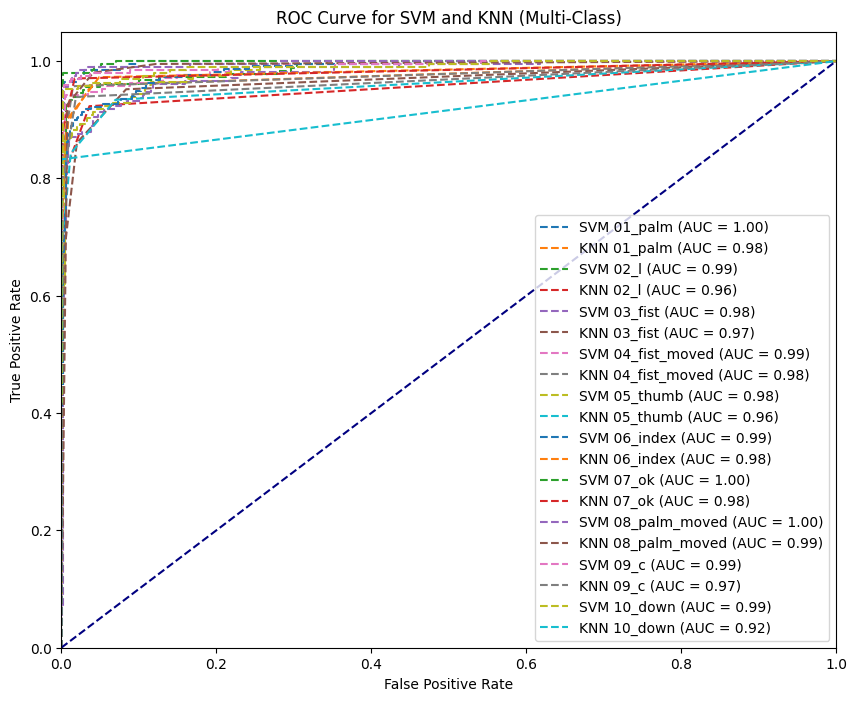

In [ ]:
import numpy as np

# Assuming y_val_bin and y_val_score_knn are already defined
# Get unique class names from y_val_bin
class_names = np.unique(y_val_bin)

# Initialize dictionaries to store FPR, TPR, and ROC AUC for SVM
fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

# Loop through each class to compute ROC curve and ROC AUC for SVM
for i, class_name in enumerate(unique_classes):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_val_bin[:, i], y_val_score_svm[:, i])
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

# Compute ROC curve and ROC AUC for each class for KNN
fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()

for i, class_name in enumerate(unique_classes):
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_val_bin[:, i], y_val_score_knn[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

# Plot ROC curves for both SVM and KNN
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(unique_classes):
    plt.plot(fpr_svm[i], tpr_svm[i], label=f'SVM {class_name} (AUC = {roc_auc_svm[i]:.2f})', linestyle='--')
    plt.plot(fpr_knn[i], tpr_knn[i], label=f'KNN {class_name} (AUC = {roc_auc_knn[i]:.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM and KNN (Multi-Class)')
plt.legend(loc='lower right')
plt.show()


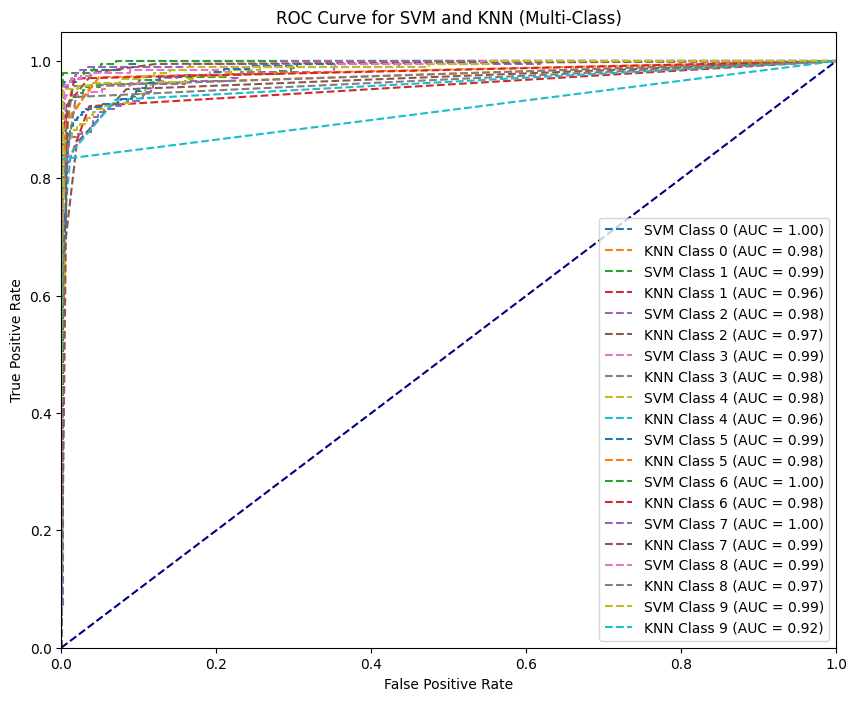

In [ ]:
# Initialize dictionaries to store FPR, TPR, and ROC AUC for SVM
fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

# Loop through each class to compute ROC curve and ROC AUC for SVM
for i in range(10):  # Assuming there are 10 classes
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_val_bin[:, i], y_val_score_svm[:, i])
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

# Compute ROC curve and ROC AUC for each class for KNN
fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()

for i in range(10):  # Assuming there are 10 classes
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_val_bin[:, i], y_val_score_knn[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

# Plot ROC curves for both SVM and KNN
plt.figure(figsize=(10, 8))
for i in range(10):  # Assuming there are 10 classes
    plt.plot(fpr_svm[i], tpr_svm[i], label=f'SVM Class {i} (AUC = {roc_auc_svm[i]:.2f})', linestyle='--')
    plt.plot(fpr_knn[i], tpr_knn[i], label=f'KNN Class {i} (AUC = {roc_auc_knn[i]:.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM and KNN (Multi-Class)')
plt.legend(loc='lower right')
plt.show()


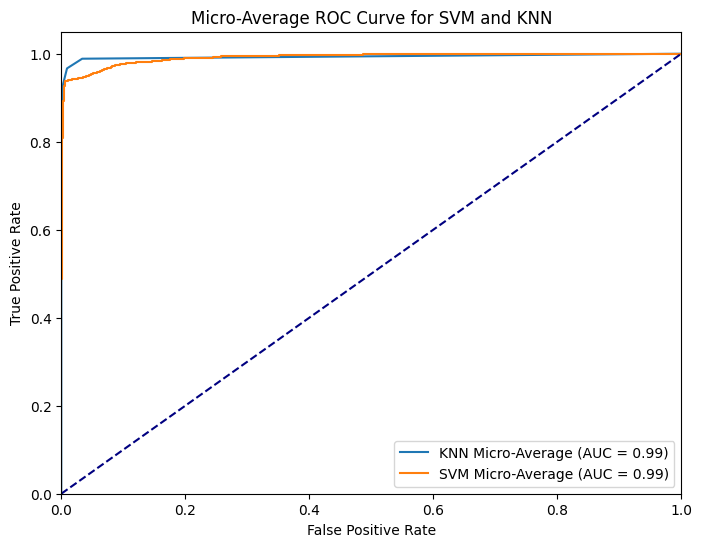

In [ ]:
#MICRO AVERAGE

from sklearn.metrics import roc_auc_score

# Compute micro-average FPR and TPR for KNN and SVM
y_val_score_micro_knn = np.concatenate([y_val_score_knn[:, i] for i in range(len(unique_classes))])
y_val_bin_micro = np.concatenate([y_val_bin[:, i] for i in range(len(unique_classes))])

fpr_micro_knn, tpr_micro_knn, _ = roc_curve(y_val_bin_micro, y_val_score_micro_knn)
roc_auc_micro_knn = auc(fpr_micro_knn, tpr_micro_knn)

y_val_score_micro_svm = np.concatenate([y_val_score_svm[:, i] for i in range(len(unique_classes))])
fpr_micro_svm, tpr_micro_svm, _ = roc_curve(y_val_bin_micro, y_val_score_micro_svm)
roc_auc_micro_svm = auc(fpr_micro_svm, tpr_micro_svm)

# Plot micro-average ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_micro_knn, tpr_micro_knn, label=f'KNN Micro-Average (AUC = {roc_auc_micro_knn:.2f})')
plt.plot(fpr_micro_svm, tpr_micro_svm, label=f'SVM Micro-Average (AUC = {roc_auc_micro_svm:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Average ROC Curve for SVM and KNN')
plt.legend(loc='lower right')
plt.show()
